<a href="https://colab.research.google.com/github/tdineth/Neural-Network---Deep-Learning-CO5420-4th-sem/blob/main/Learn/ZeroR_%26_OneR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
!wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

--2026-05-16 03:54:35--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.001s  

2026-05-16 03:54:35 (17.5 MB/s) - ‘diabetes.csv’ saved [23873/23873]



In [4]:
df = pd.read_csv("diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# ZeroR Classifier

ZeroR or zero rule classifier is a naive approach to classify a dataset. It is purely based on the target and ignores the other independent attributes.

Application: The ZeroR classifier is used as a baseline for other classifiers. Other classifiers should do better than this to proove their capabilities.

Let's see an example of this.

In [6]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


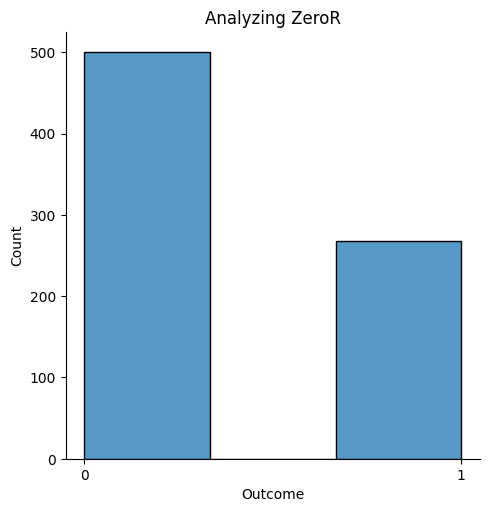

In [7]:
sns.displot(data=df["Outcome"],bins=3,kde=False)
plt.title("Analyzing ZeroR")
plt.xticks([0,1])
plt.show()

Now, if i say that I have a rule to classify the dataset. The rule is :

`Outcome = 0 `

How much accurate is it? Note that 500 times the outcome is 0 and 268 times it is 1.

    = 500 / (500+268)
    
    = 500 / 768

    = 0.651

Thus, the accuracy is 65.1% . Other classifers will have to do better than this.

**Note** : I have not divided the data set into training and test-set to make everything simple and easy to understand.



---



# OneR Classifier ##


Unlike zeroR, oneR considers each of the attributes. It make rules for each attribute, and selectes the rule which generates highest accuracy. The algorithm is:

            
    For each predictor,

         For each value of that predictor, make a rule as follows;

               Count how often each value of target (class) appears

               Find the most frequent class

               Make the rule assign that class to this value of the predictor

         Calculate the total error of the rules of each predictor
     
    Choose the predictor with the smallest total error


[Algorithm Source: Saed Sayad OneR](https://www.saedsayad.com/oner.htm)

`It basically generates one level dicision tree.`

Let's see it in action:

**Note**:
1. As we have `numerical data` over a wide range, there can be many rules. Like for attribute 'Age', rule can be age<17, age<12, age<24, age<34 ... etc. Thus, we will make 3 categories :

    0 = young, 1 = mid, 2 = old
    
2. The code will become complex and uncessarily lengthy, thus, using only `Age` attribute.    

In [9]:
# Our criteria:
# 0 = young, 1 = mid, 2 = old

column_age = []

for age in df['Age']:
  if age < 25:
    column_age.append("0")
  elif age>25 and age<45:
    column_age.append("1")
  else:
    column_age.append("2")

# addding new column to data
df["Age_Categorical"] = column_age

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Categorical
0,6,148,72,35,0,33.6,0.627,50,1,2
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2.288,33,1,1


In [13]:
for i in range(0,3):
  print("If category",i,", number of outcomes(0): ",len(df[(df['Age_Categorical']==str(i)) & (df["Outcome"]==0)]))
  print("If category",i,", number of outcomes(1): ",len(df[(df['Age_Categorical']==str(i)) & (df["Outcome"]==1)]))

If category 0 , number of outcomes(0):  188
If category 0 , number of outcomes(1):  31
If category 1 , number of outcomes(0):  211
If category 1 , number of outcomes(1):  157
If category 2 , number of outcomes(0):  101
If category 2 , number of outcomes(1):  80


So, If we have a set of rules only for attribute `Age_Categorical` which says:

    if, Age_Categorical = 0 then Outcome=0
    if, Age_Categorical = 1 then Outcome=0  
    else Age_Categorical = 2 then Outcome=0,
    
the accuracy of the model will be:

    = (188 + 211 + 101) / (188 + 31 + 211 + 157 + 101 + 80)
    = 500/768
    = 0.651
    
The accuracy will be 65.1% . Same as the zeroR . Hmmmm     